# Graphura	Instagram	Content	Intelligence

Project	Objective
The	objective	of	this	machine	learning	system	is	to	predict	the	performance	of	Instagram	posts	and	support	data-driven	content	planning for	Graphura.	Each	post	is	classified	into	one	of	three	performance	categories	based	on	historical	engagement	rate thresholds:-High	Performance	-Medium	Performance	-Low	Performance"

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv ('Graphura Social Media Data.csv')

In [3]:
df.head()

,Post ID,Platform,Duration (sec),Date,Post type,Views,Reach,Likes,Shares,Follows,Comments,Saves,Engagement Rate,Hashtag Counts,Day,Day numbers,Hashtag
0,1,Linkedin,NaN,04-11-2025,Image,358,98,13,0,0,0,0,13.265306,0,Tuesday,3,NaN
1,2,Linkedin,NaN,05-11-2025,Image,380,115,19,0,0,0,0,16.521739,0,Wednesday,4,NaN
2,3,Linkedin,NaN,06-11-2025,Image,389,93,11,0,0,0,0,11.827957,0,Thursday,5,NaN
3,4,Linkedin,NaN,07-11-2025,Carousel,334,78,13,0,0,0,0,16.666667,0,Friday,6,NaN
4,5,Linkedin,NaN,08-11-2025,Image,337,81,17,0,0,0,0,20.987654,0,Saturday,7,NaN


# 1] Data Cleaning and Preprocessing

In [4]:
df.info()
df.isnull().sum()
df.columns	=	df.columns.str.strip()
df.fillna('0',inplace=True)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post ID          175 non-null    int64  
 1   Platform         175 non-null    object 
 2   Duration (sec)   85 non-null     float64
 3   Date             175 non-null    object 
 4   Post type        175 non-null    object 
 5   Views            175 non-null    int64  
 6   Reach            175 non-null    int64  
 7   Likes            175 non-null    int64  
 8   Shares           175 non-null    int64  
 9   Follows          175 non-null    int64  
 10  Comments         175 non-null    int64  
 11  Saves            175 non-null    int64  
 12  Engagement Rate  175 non-null    float64
 13  Hashtag Counts   175 non-null    int64  
 14  Day              175 non-null    object 
 15  Day numbers      175 non-null    int64  
 16  Hashtag          84 non-null     object 
dtypes: float64(2), i

,Post ID,Platform,Duration (sec),Date,Post type,Views,Reach,Likes,Shares,Follows,Comments,Saves,Engagement Rate,Hashtag Counts,Day,Day numbers,Hashtag
0,1,Linkedin,0,04-11-2025,Image,358,98,13,0,0,0,0,13.265306,0,Tuesday,3,0
1,2,Linkedin,0,05-11-2025,Image,380,115,19,0,0,0,0,16.521739,0,Wednesday,4,0
2,3,Linkedin,0,06-11-2025,Image,389,93,11,0,0,0,0,11.827957,0,Thursday,5,0
3,4,Linkedin,0,07-11-2025,Carousel,334,78,13,0,0,0,0,16.666667,0,Friday,6,0
4,5,Linkedin,0,08-11-2025,Image,337,81,17,0,0,0,0,20.987654,0,Saturday,7,0


In [5]:
df["Post type"].fillna(0)

0         Image
1         Image
2         Image
3      Carousel
4         Image
         ...   
170       Image
171    Carousel
172       Image
173       Image
174       Image
Name: Post type, Length: 175, dtype: object

In [6]:
clean_df = df.copy()

In [7]:
clean_df.head()

,Post ID,Platform,Duration (sec),Date,Post type,Views,Reach,Likes,Shares,Follows,Comments,Saves,Engagement Rate,Hashtag Counts,Day,Day numbers,Hashtag
0,1,Linkedin,0,04-11-2025,Image,358,98,13,0,0,0,0,13.265306,0,Tuesday,3,0
1,2,Linkedin,0,05-11-2025,Image,380,115,19,0,0,0,0,16.521739,0,Wednesday,4,0
2,3,Linkedin,0,06-11-2025,Image,389,93,11,0,0,0,0,11.827957,0,Thursday,5,0
3,4,Linkedin,0,07-11-2025,Carousel,334,78,13,0,0,0,0,16.666667,0,Friday,6,0
4,5,Linkedin,0,08-11-2025,Image,337,81,17,0,0,0,0,20.987654,0,Saturday,7,0


In [8]:
clean_df.drop(columns=["Date","Post ID","Duration (sec)"],	inplace=True)

In [9]:
clean_df.head()

,Platform,Post type,Views,Reach,Likes,Shares,Follows,Comments,Saves,Engagement Rate,Hashtag Counts,Day,Day numbers,Hashtag
0,Linkedin,Image,358,98,13,0,0,0,0,13.265306,0,Tuesday,3,0
1,Linkedin,Image,380,115,19,0,0,0,0,16.521739,0,Wednesday,4,0
2,Linkedin,Image,389,93,11,0,0,0,0,11.827957,0,Thursday,5,0
3,Linkedin,Carousel,334,78,13,0,0,0,0,16.666667,0,Friday,6,0
4,Linkedin,Image,337,81,17,0,0,0,0,20.987654,0,Saturday,7,0


# 2] Feature Extraction and Selection

In [10]:
clean_df["Engagement Rate by Reach (%)"] = (
    (
    	clean_df["Likes"].fillna(0) + clean_df["Comments"].fillna(0) + clean_df["Shares"].fillna(0) + clean_df["Views"].fillna(0) + clean_df["Saves"].fillna(0))
    /	clean_df["Reach"].replace(0,	np.nan))	*	100
clean_df["Engagement Rate by Reach (%)"]	=	clean_df["Engagement Rate by Reach (%)"].clip(upper=100)

In [11]:
clean_df["Engagement Rate by Views (%)"] = (
		(
			clean_df["Likes"].fillna(0) + clean_df["Comments"].fillna(0) + clean_df["Shares"].fillna(0) + clean_df["Reach"].fillna(0) + clean_df["Saves"].fillna(0)
		)/	clean_df["Views"].replace(0,	np.nan))	*	100
clean_df["Engagement Rate by Views (%)"]	=	clean_df["Engagement Rate by Views (%)"].clip(upper=100)

In [12]:
clean_df["Avg_Engagement_Rate (%)"]	= ( clean_df["Engagement Rate by Reach (%)"] + clean_df["Engagement Rate by Views (%)"]) / 2

In [13]:
clean_df["Avg_Engagement_Rate (%)"].median()

66.89189189189189

In [14]:
print(clean_df[["Engagement Rate by Reach (%)","Engagement Rate by Views (%)",	"Avg_Engagement_Rate (%)"]].describe())

       Engagement Rate by Reach (%)  Engagement Rate by Views (%)  \
count                         175.0                    175.000000   
mean                          100.0                     39.150224   
std                             0.0                     19.221596   
min                           100.0                     13.084112   
25%                           100.0                     26.217949   
50%                           100.0                     33.783784   
75%                           100.0                     48.615340   
max                           100.0                     97.183099   

       Avg_Engagement_Rate (%)  
count               175.000000  
mean                 69.575112  
std                   9.610798  
min                  56.542056  
25%                  63.108974  
50%                  66.891892  
75%                  74.307670  
max                  98.591549  


In [15]:
import	pandas	as	pd
bins	=	[0,	63,	74,	100]
labels	=	["Low",	"Medium",	"High"]
clean_df["Performance_Class"]	=	pd.cut(
				clean_df["Engagement Rate by Views (%)"],
				bins=bins,
				labels=labels,
				right=False,
				include_lowest=True
)

In [16]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Platform                      175 non-null    object  
 1   Post type                     175 non-null    object  
 2   Views                         175 non-null    int64   
 3   Reach                         175 non-null    int64   
 4   Likes                         175 non-null    int64   
 5   Shares                        175 non-null    int64   
 6   Follows                       175 non-null    int64   
 7   Comments                      175 non-null    int64   
 8   Saves                         175 non-null    int64   
 9   Engagement Rate               175 non-null    float64 
 10  Hashtag Counts                175 non-null    int64   
 11  Day                           175 non-null    object  
 12  Day numbers                   175 non-null    int6

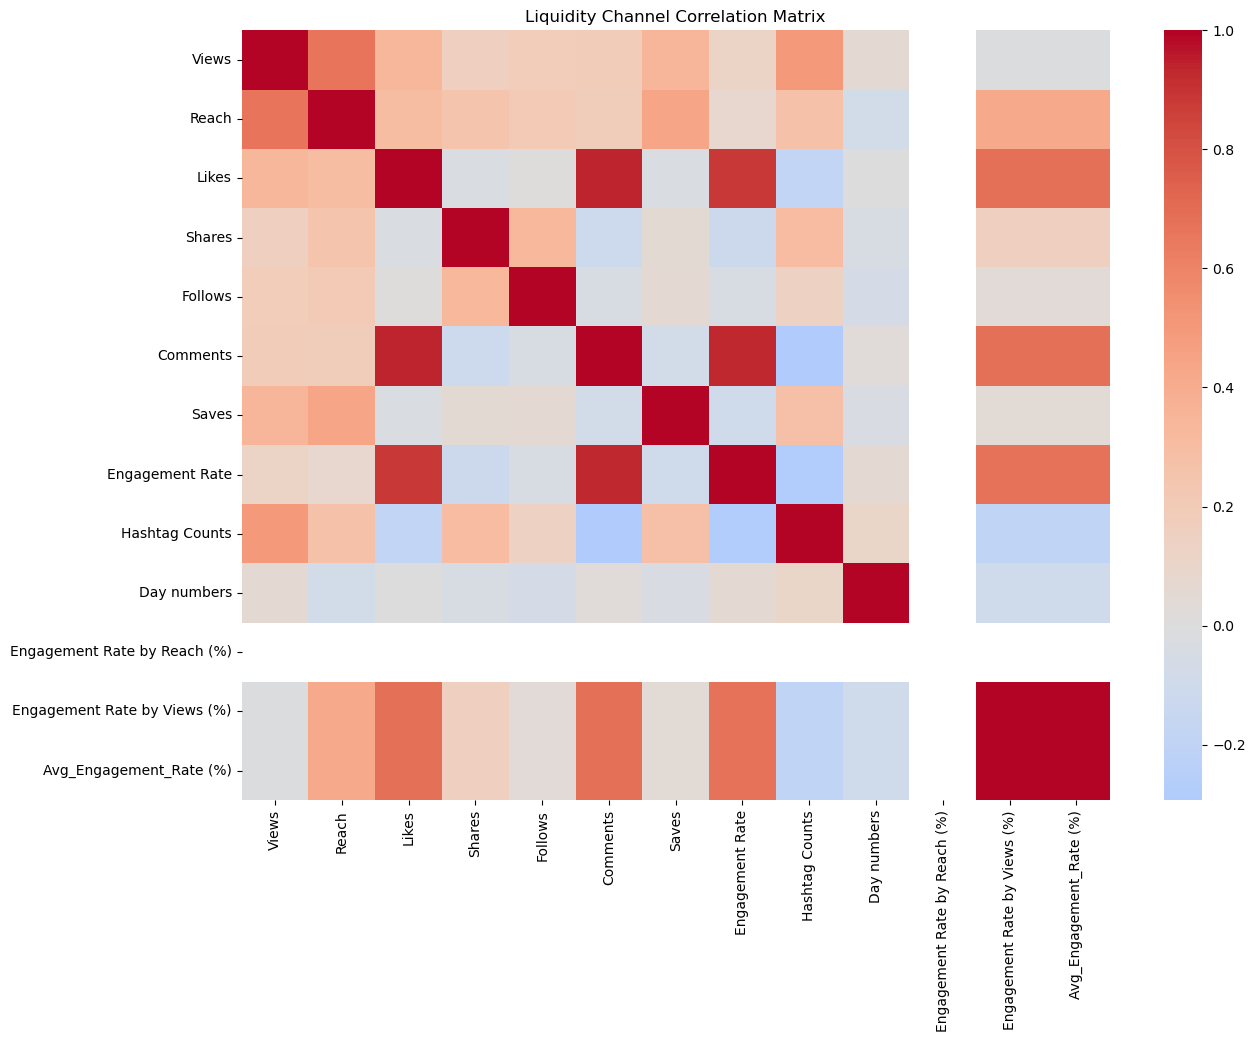

In [17]:
import	seaborn	as	sns
import	matplotlib.pyplot	as	plt
corr	=	clean_df.select_dtypes(include=["int64",	"float64"]).corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr,	cmap="coolwarm",	center=0)
plt.title("Liquidity Channel Correlation Matrix")
plt.show()

In [47]:
from	sklearn.model_selection	import	train_test_split
clean_df.columns
clean_df = clean_df.drop(["Hashtag","Engagement Rate by Reach (%)","Engagement Rate by Views (%)",],axis=1)
x	=	clean_df
y	=	clean_df["Performance_Class"]
xtrain,	xtest,	ytrain,	ytest	=	train_test_split(x,y,
                                                     test_size=0.2,
                                                     random_state=42,
                                                     stratify=y
                                                    )

KeyError: "['Hashtag', 'Engagement Rate by Reach (%)', 'Engagement Rate by Views (%)'] not found in axis"

In [19]:
x.columns

Index(['Platform', 'Post type', 'Views', 'Reach', 'Likes', 'Shares', 'Follows',
       'Comments', 'Saves', 'Engagement Rate', 'Hashtag Counts', 'Day',
       'Day numbers', 'Performance_Class'],
      dtype='object')

In [ ]:
num_cols	=	["Hashtag Counts","Day numbers","Avg_Engagement_Rate (%)"]
cat_cols	=	["Platform",	"Post type"]
target	=	"Performance_Class"

In [21]:
from	sklearn.pipeline	import	Pipeline
from	sklearn.compose	import	ColumnTransformer
from	sklearn.impute	import	SimpleImputer
from	sklearn.preprocessing	import	RobustScaler,	OneHotEncoder
num_pipeline	=	Pipeline([
("imputer",	SimpleImputer(strategy="mean")),
("scaler",	RobustScaler())
])
cat_pipeline	=	Pipeline([
("imputer",	SimpleImputer(strategy="most_frequent")),
("encoder",	OneHotEncoder(
handle_unknown="ignore",
sparse_output=False			#	CRITICAL	FIX
))
])
preprocessor	=	ColumnTransformer([
("num",	num_pipeline,	num_cols),
("cat",	cat_pipeline,	cat_cols),
])
remainder="drop"

In [22]:
xctrain_processed	=	preprocessor.fit_transform(xtrain)
xctest_processed	=	preprocessor.transform(xtest)

# 3] Model Training

In [23]:
from	sklearn.metrics	import	accuracy_score,	classification_report
def	evaluate_model(model, xtest, ytest, name):
    preds = model.predict(xtest)
    acc	= accuracy_score(ytest, preds)
    print(f"\n{name}")
    print("Accuracy:",	acc)
    print(classification_report(ytest, preds))
    return	acc

In [24]:
# 1] Logistic Regression

In [25]:
from	sklearn.linear_model	import	LogisticRegression
from	sklearn.model_selection	import	GridSearchCV
log_pipe	=	Pipeline([
("preprocessing",	preprocessor),
("model",	LogisticRegression(max_iter=200))
])
log_params	=	{
"model__C":	[0.01,	0.1,	1,	10,	100],
"model__solver":	["lbfgs"],
"model__class_weight":	[None,	"balanced"]
}
log_grid	=	GridSearchCV(
log_pipe,
log_params,
cv=5,
scoring="accuracy"
)
log_grid.fit(xtrain,	ytrain)
best_log	=	log_grid.best_estimator_
evaluate_model(best_log,	xtest,	ytest,	"Logistic	Regression")


Logistic	Regression
Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         2
         Low       0.86      1.00      0.92        30
      Medium       0.00      0.00      0.00         3

    accuracy                           0.86        35
   macro avg       0.29      0.33      0.31        35
weighted avg       0.73      0.86      0.79        35



0.8571428571428571

In [26]:
# 2] Random Forest

In [27]:
from	sklearn.ensemble	import	RandomForestClassifier
rf_pipe	=	Pipeline([
("preprocessing",	preprocessor),
("model",	RandomForestClassifier(random_state=42))
])
rf_params	=	{
"model__n_estimators":	[100,	200,	300],
"model__max_depth":	[None,	10,	20],
"model__min_samples_split":	[2,	5]
}
rf_grid	=	GridSearchCV(
rf_pipe,
rf_params,
cv=5,
scoring="accuracy",
n_jobs=-1
)
rf_grid.fit(xtrain,	ytrain)
best_rf	=	rf_grid.best_estimator_
evaluate_model(best_rf,	xtest,	ytest,	"Random	Forest")


Random	Forest
Accuracy: 0.8
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         2
         Low       0.90      0.87      0.88        30
      Medium       0.50      0.67      0.57         3

    accuracy                           0.80        35
   macro avg       0.47      0.51      0.48        35
weighted avg       0.81      0.80      0.80        35



0.8

In [28]:
# 3] Decision Tree

In [29]:
from	sklearn.tree	import	DecisionTreeClassifier
dt_pipe	=	Pipeline([
("preprocessing",	preprocessor),
("model",	DecisionTreeClassifier(random_state=42))
])
dt_params	=	{
"model__max_depth":	[None,	5,	10,	20],
"model__min_samples_split":	[2,	5,	10]
}
dt_grid	=	GridSearchCV(
dt_pipe,
dt_params,
cv=5,
scoring="accuracy"
)
dt_grid.fit(xtrain,	ytrain)
best_dt	=	dt_grid.best_estimator_
evaluate_model(best_dt,	xtest,	ytest,	"Decision	Tree")


Decision	Tree
Accuracy: 0.7428571428571429
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         2
         Low       0.89      0.80      0.84        30
      Medium       0.50      0.67      0.57         3

    accuracy                           0.74        35
   macro avg       0.46      0.49      0.47        35
weighted avg       0.80      0.74      0.77        35



0.7428571428571429

In [30]:
import	pandas	as	pd
from	sklearn.metrics	import	accuracy_score
final_results	=	pd.DataFrame([
["Logistic Regression",	accuracy_score(ytest,	best_log.predict(xtest))*100],
["Decision Tree",	accuracy_score(ytest,	best_dt.predict(xtest))*100],
["Random Forest",	accuracy_score(ytest,	best_rf.predict(xtest))*100],
],	columns=["Model",	"Accuracy"])
final_results.sort_values("Accuracy",	ascending=False)

,Model,Accuracy
0,Logistic Regression,85.714286
2,Random Forest,80.000000
1,Decision Tree,74.285714


In [31]:
accurate_model	=	best_log

In [32]:
accurate_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Hashtag Counts',
                                                   'Day numbers']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Platform', 'Post type'])])),
                ('model', LogisticRegression(C=0.01, max_iter=200))])

# 4] Model Testing

In [46]:
import	pandas	as	pd
sample_data =	pd.DataFrame([{
"Platform":	"Instagram",
"Hashtag Counts":	3,
"Day numbers": 7,
"Post type":	"video",
}])
print(accurate_model.predict(sample_data))

['Low']


# 5] Saving for Deployment of Model 

In [38]:
import	os,	joblib
import	sys, sklearn
print(os.getcwd())
os.makedirs("models",	exist_ok=True)
print(os.listdir("models"))
joblib.dump(accurate_model,	"accurate_model.joblib")

c:\Users\flowp\Desktop\GRAPHURA DSA\Project 1 (13-2-2026)\Final Implementation\Submission
[]


['accurate_model.joblib']